# EDA & Data Preparation — Telco Customer Churn
Loads the raw dataset, cleans it, explores it, and saves a cleaned, feature-engineered
version for the model training notebook to pick up.


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

df = pd.read_csv('new_churn.csv')   
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. First Look

- `customerID` — unique identifier, not a predictive feature, will be dropped
- `TotalCharges` — loaded as text; needs to be converted to numeric
- `Churn` — target, currently 'Yes'/'No' text


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Fix Data Types

`TotalCharges` is stored as a string in the raw file because a handful of rows contain
blank values instead of numbers — pandas falls back to text for the whole column.
Coercing to numeric turns those blanks into NaN, which we can then inspect and handle.


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing after coercion:', df['TotalCharges'].isnull().sum())
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Missing after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## 4. Handle Missing Values

The blank `TotalCharges` rows all correspond to **new customers with `tenure == 0`**
(they haven't been billed a full cycle yet) — so 0 is the correct value here, not a
median/mean imputation. This is a real zero, not a genuinely missing measurement.


In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

assert df.isnull().sum().sum() == 0, "Still have missing values!"
print("No missing values remain.")


No missing values remain.


## 5. Target Distribution


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


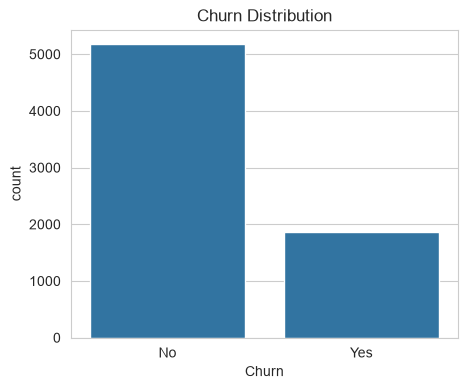

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(1))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()


**Note:** the classes are imbalanced (~73% No / ~27% Yes). Worth revisiting in the
model training notebook — options include class-weighting or resampling (e.g. SMOTE),
rather than assuming plain accuracy is a good metric here.


## 6. Numeric Features vs. Churn

`tenure`, `MonthlyCharges`, `TotalCharges` are the three numeric features. Compare
their distributions split by churn.


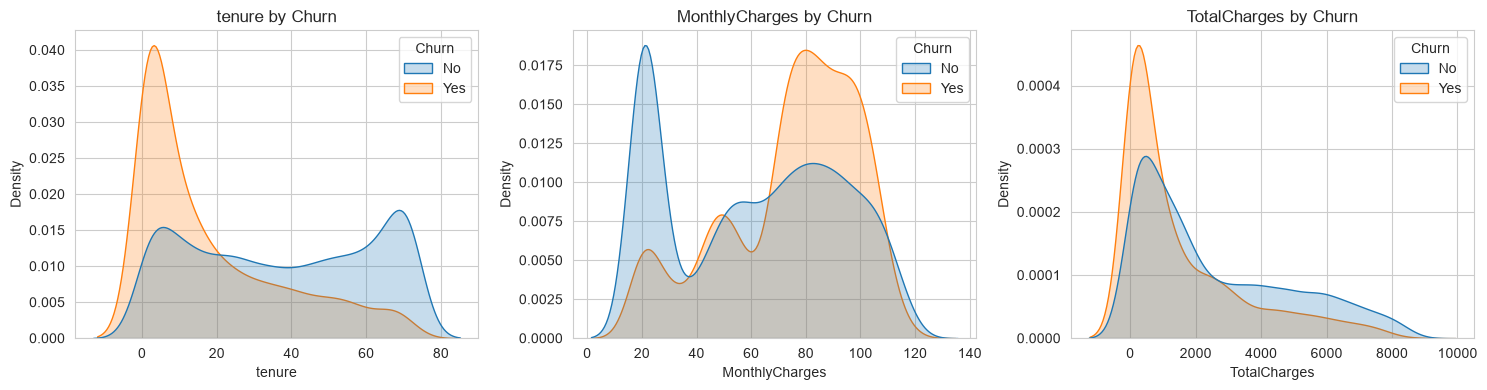

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', ax=ax, fill=True, common_norm=False)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


## 7. Categorical Features vs. Churn

Churn rate broken down by each categorical column — this is usually where the clearest
business signal shows up (e.g. contract type, internet service, payment method).


In [8]:
categorical_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

for col in categorical_cols:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    print(f"\n--- {col} ---")
    print(churn_rate.sort_values(ascending=False).round(3))



--- gender ---
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

--- Partner ---
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.267
No     0.249
Name: Churn, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: Churn, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     0.391
Yes          

C:\Users\Mamtaam\AppData\Local\Temp\ipykernel_5020\1144427243.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])


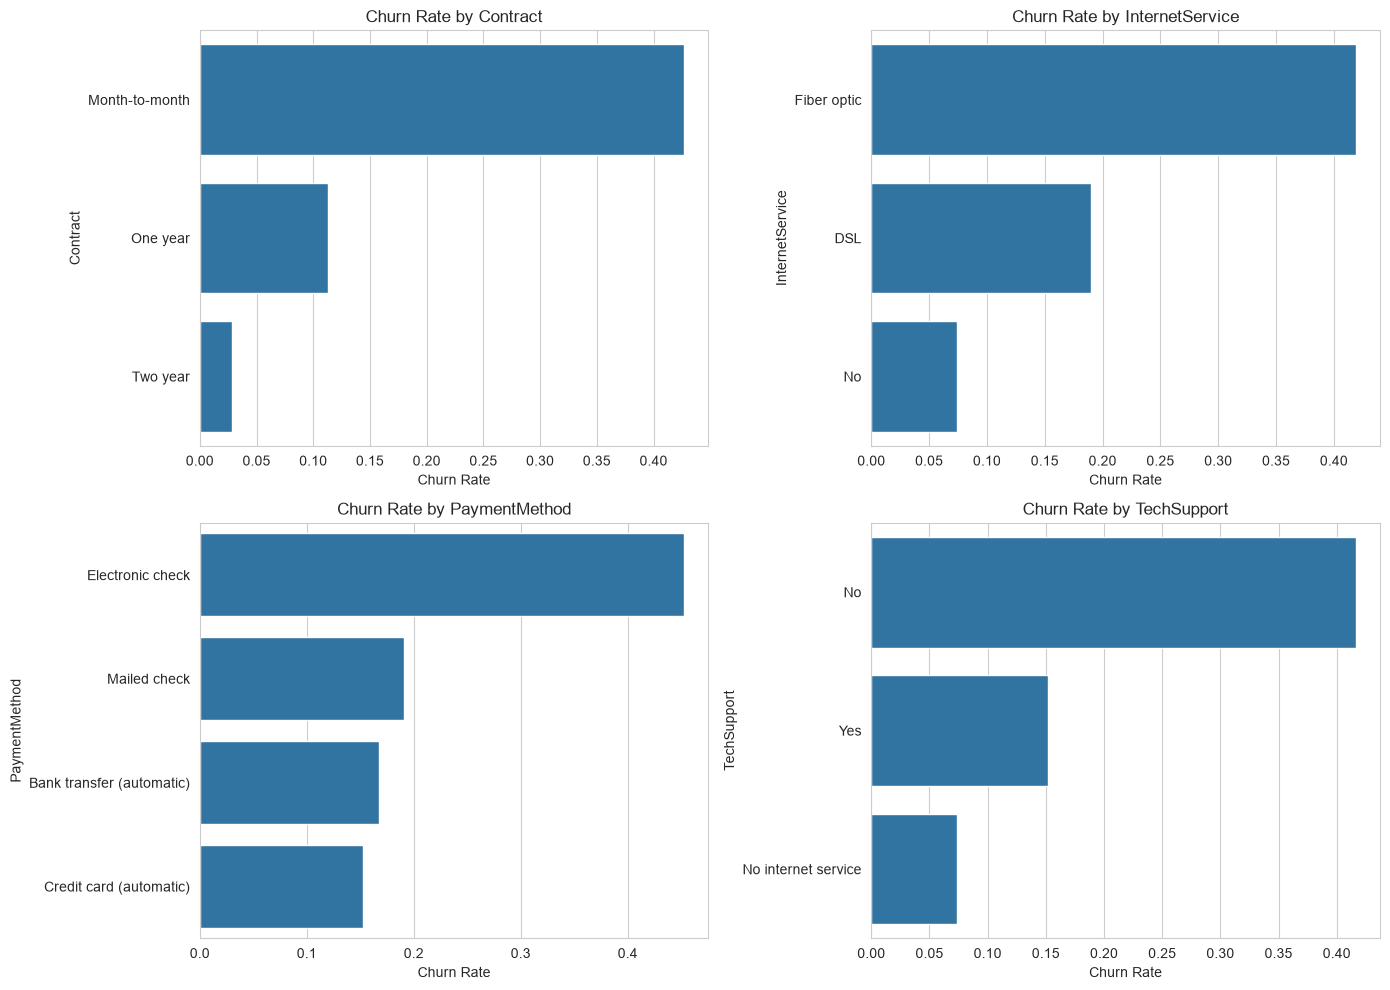

In [9]:
# Visualize a few of the most business-relevant ones
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, key_cats):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index, ax=ax)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()


## 8. Correlation Among Numeric Features


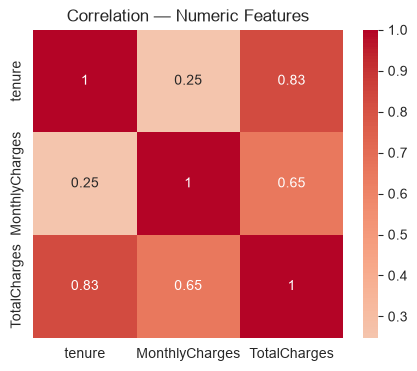

In [10]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation — Numeric Features')
plt.show()


## 9. Encode Target & Drop Identifier

Convert `Churn` to 0/1 and drop `customerID` — it's a unique key, not a predictive signal.
Everything else is left as-is (raw categorical text); encoding of categorical *features*
(One-Hot) happens in the model training notebook, not here, since scaling/encoding
choices belong with the train/test split to avoid leakage.


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_clean = df.drop(columns=['customerID'])

print(df_clean.shape)
df_clean.head()


(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 10. Save Cleaned Dataset

This is the file the model training notebook (`MODEL_Training.ipynb`) will load as its
starting point.


In [12]:
df_clean.to_csv('Telco_Customer_Churn_clean.csv', index=False)
print("Saved: Telco_Customer_Churn_clean.csv")


Saved: Telco_Customer_Churn_clean.csv


## Summary

- Original shape: 7,043 rows x 21 columns
- Fixed `TotalCharges` dtype (text -> numeric), filled 11 blank rows with 0 (all `tenure == 0`)
- No other missing values
- Target is imbalanced (~73% / ~27%) — flagged for the modeling stage
- Clear churn signal by eye in `Contract`, `InternetService`, `TechSupport`, `PaymentMethod` — tree-based models should pick these up well
- Dropped `customerID`, encoded `Churn` to 0/1, saved cleaned file for model training
